Theory of working: https://courses.cs.washington.edu/courses/cse576/16sp/Slides/10_ImageStitching.pdf

TODO pogledati detaljno parametre: https://github.com/OpenStitching/stitching/blob/main/stitching/stitcher.py



## Imports

In [2]:
!pip install stitching

In [13]:
from stitching import Stitcher
from matplotlib import pyplot as plt
import cv2
import numpy as np

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Helper functions

In [26]:
def plot_image(imgs,
               figsize=(5,5)):
    if not isinstance(imgs, list):
        imgs = [imgs]

    num_images = len(imgs)
    cols = num_images
    rows = (num_images + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    # Normalize axes to flat iterable
    if num_images == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = np.array(axes).flatten()
    else:
        axes = axes.flatten()

    for i, image in enumerate(imgs):
        axes[i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[i].axis('off')

    # Hide any extra axes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

## Stitcher initialization, image selection

In [6]:
'''
  Initialize stitcher object.
'''
stitcher = Stitcher(detector="sift",          # options: sift, org, surf
                    confidence_threshold=0.2)

In [12]:
image_path_list = ["/content/drive/MyDrive/ERC/Panorama/left.jpg",
                   "/content/drive/MyDrive/ERC/Panorama/middle.jpg",
                   "/content/drive/MyDrive/ERC/Panorama/right.jpg"]

left_image = cv2.imread(image_path_list[0])
middle_image = cv2.imread(image_path_list[1])
right_image = cv2.imread(image_path_list[2])

image_list = [left_image,
              middle_image,
              right_image]

In [28]:
'''
  Run the algorithm. Both produces same output.
'''
panorama = stitcher.stitch(image_path_list)
# panorama = stitcher.stitch(image_list)

In [29]:
'''
  Save image
'''
cv2.imwrite('panorama.jpg', panorama)

True

## Show images

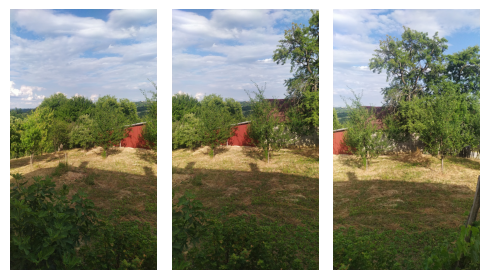

In [30]:
'''
  Input images
'''
plot_image(image_list)

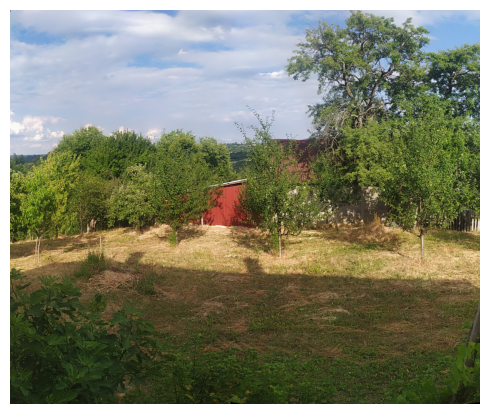

In [31]:
'''
  Output image
'''
plot_image(panorama)